# 06 · Model Explainability & Error Analysis

## 1. Objective
Understand *why* the models predict what they predict: tree/forest feature importances, Logistic Regression coefficients and odds ratios, SHAP explanations, and an analysis of the mistakes.

> ⚠️ *Educational demonstration - not for medical diagnosis or clinical decisions.*

## Concepts
- **Feature importance (trees)** - how much a feature reduced impurity (Gini/entropy) across all splits (for forests: averaged over trees). It shows what the model *uses*, not causation; it can favour features with many possible split points and splits importance among correlated features.
- **One-hot mapping** - one-hot encoding turns one category into several columns; we sum their importances back onto the original feature.
- **Logistic Regression coefficient** - change in log-odds of CKD for +1 unit of the (scaled) feature. **Odds ratio = exp(coef)**: >1 raises the odds of CKD, <1 lowers them. For scaled numerics "+1 unit" means +1 standard deviation; for binary flags it means *yes vs no*. These describe the model, **not causal effects**, and depend on the preprocessing.
- **SHAP** - assigns each feature a contribution to each individual prediction (from game theory), giving both global and per-patient explanations.

## 2. Imports

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(name): plt.savefig(FIG / name, bbox_inches="tight", dpi=150)

In [2]:
from src.evaluate import (load_models, load_selection, get_data, plot_importances, logistic_coefficients,
                          plot_coefficients, error_analysis, shap_analysis, tree_importance)
from src.feature_engineering import FEATURE_LABELS
models, sel = load_models(), load_selection()
X_train, X_test, y_train, y_test = get_data()
print("Final model:", sel["final_model"])

Final model: Logistic Regression


## 3. Decision Tree and Random Forest feature importance
One-hot columns are aggregated back to their original clinical feature.

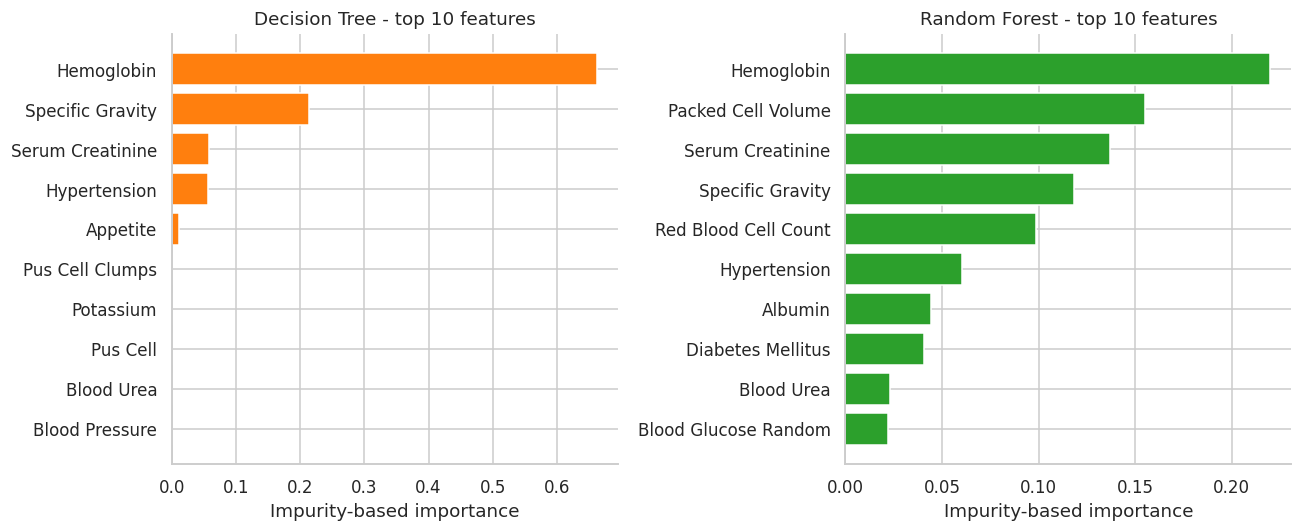

,Decision Tree,Random Forest
al,NaN,0.0443
appet,0.0115,NaN
bgr,NaN,0.0219
bp,0.0000,NaN
bu,0.0000,0.0233
dm,NaN,0.0406
hemo,0.6618,0.2198
htn,0.0559,0.0605
pc,0.0000,NaN
pcc,0.0000,NaN


Random Forest - top raw (transformed-level) columns:


,feature,importance
0,hemo,0.2198
1,pcv,0.1548
2,sc,0.1368
3,sg,0.1182
4,rc,0.0987
5,htn_yes,0.0605
6,al,0.0443
7,dm_yes,0.0406


In [3]:
fig, tables = plot_importances(models, top_n=10); plt.show()
out = pd.DataFrame({m: t.head(10).round(4) for m, t in tables.items()}); display(out)
print("Random Forest - top raw (transformed-level) columns:"); display(tree_importance(models["Random Forest"]).head(8).round(4))

The two tree models agree on the main themes - hemoglobin/packed-cell-volume/red-cell measures, specific gravity, serum creatinine and hypertension appear near the top - but they split credit differently among *correlated* features (a single tree gives most of the credit to one red-cell feature; the forest spreads it across several). Do not read importances as "the cause of CKD".

## 4. Logistic Regression coefficients and odds ratios

Feature,Coefficient,Odds Ratio,Direction
appet_poor,3.064000,21.419000,higher odds of CKD
htn_yes,3.064000,21.418000,higher odds of CKD
sg,-2.879000,0.056000,lower odds of CKD
hemo,-2.785000,0.062000,lower odds of CKD
dm_yes,2.743000,15.536000,higher odds of CKD
pcv,-2.411000,0.090000,lower odds of CKD
sc,2.098000,8.154000,higher odds of CKD
al,1.892000,6.632000,higher odds of CKD
rc,-1.396000,0.247000,lower odds of CKD
bgr,1.352000,3.864000,higher odds of CKD


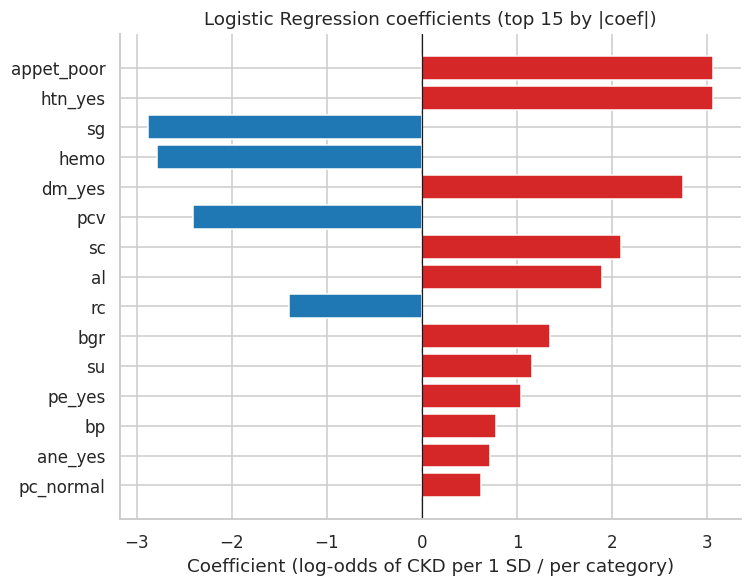

In [4]:
coef = logistic_coefficients(models["Logistic Regression"])
display(coef.round(3).style.hide(axis="index"))
plot_coefficients(coef); plt.show()

**How to read it.** A *positive* coefficient (odds ratio > 1) means that, holding other features fixed, higher values push the model toward CKD; a *negative* one (odds ratio < 1) pushes toward non-CKD. E.g. for scaled numerics, `hemo` and `sg` have negative coefficients: higher values → lower CKD odds; `sc`, `al`, `bgr` are positive.

**Cautions.** (1) Odds ratios for binary flags such as `htn_yes` and `appet_poor` are very large partly because in the training data these flags almost never occur among non-CKD patients (a near-perfect one-sided pattern); their similar magnitudes are coincidence of this, not a clinical equivalence. (2) Correlated features (hemoglobin, PCV, RBC count) share credit, so individual coefficients are unstable. (3) Everything depends on our preprocessing (imputation, scaling), and none of it is causal.

## 5. SHAP explanations (selected model)

In [5]:
imp = shap_analysis(sel["final_model"], models[sel["final_model"]], X_train, X_test)
display(imp.head(10).round(3).to_frame("mean |SHAP| (log-odds)"))

,mean |SHAP| (log-odds)
sg,2.716
hemo,2.013
pcv,1.984
al,1.636
htn_yes,1.429
dm_yes,1.309
bgr,1.187
appet_poor,1.063
su,0.957
rc,0.955


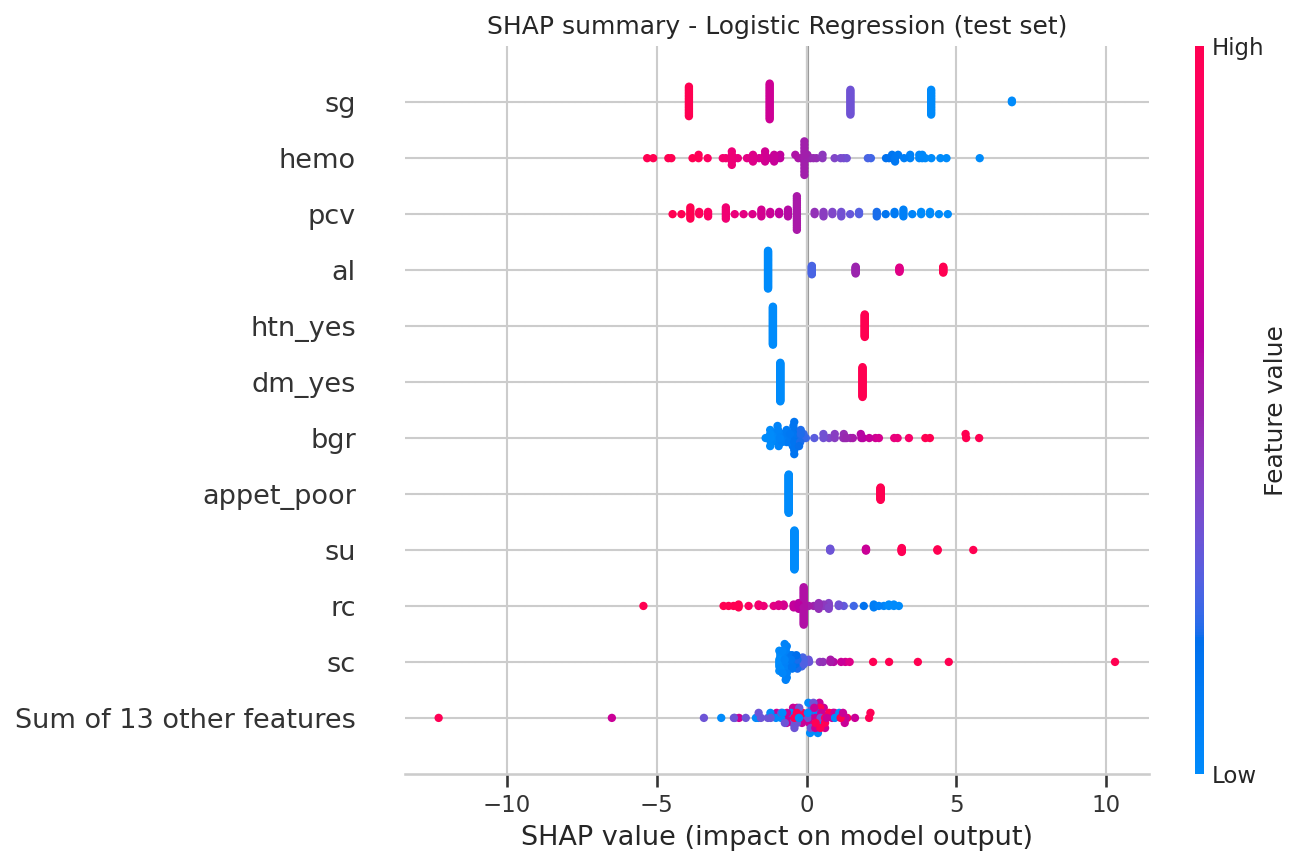

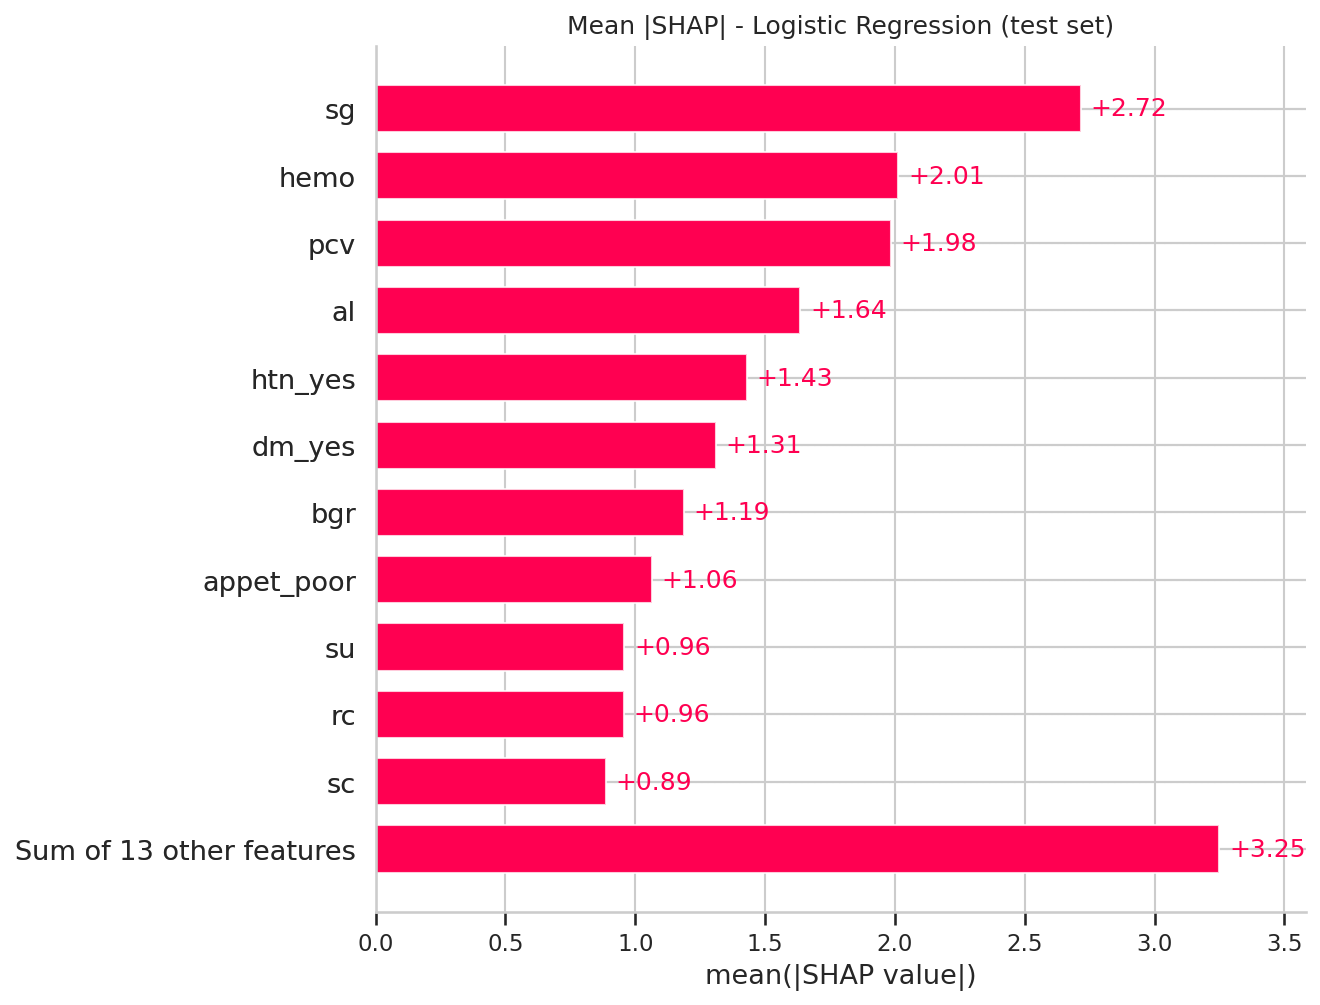

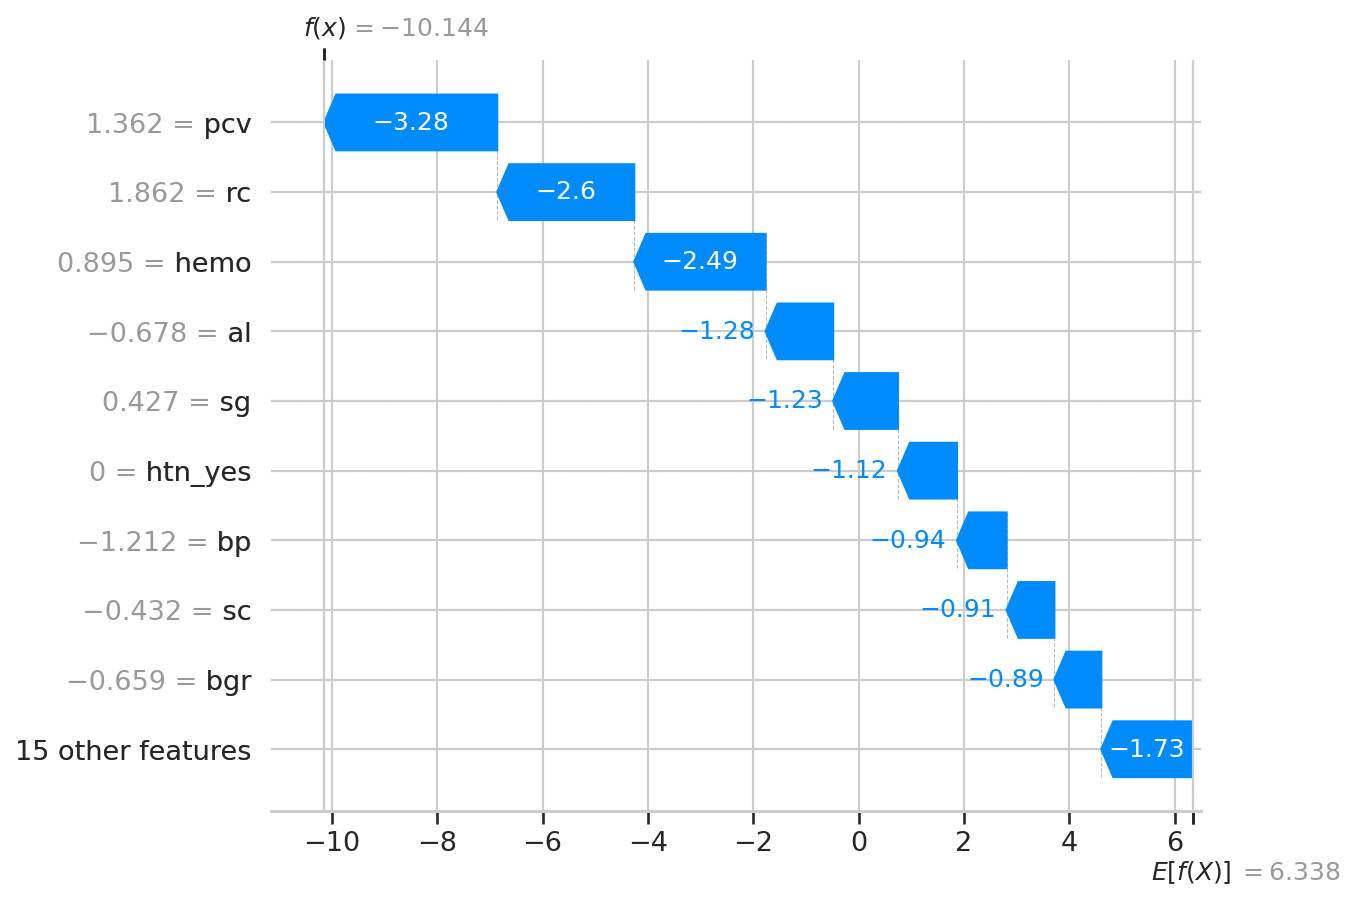

In [6]:
from IPython.display import Image
for f in ["shap_summary.png", "shap_importance_bar.png", "shap_single_prediction.png"]:
    display(Image(filename=str(FIG / f), width=650))

The summary plot shows, per test patient, how each feature pushed the prediction toward CKD (right) or away (left); colour shows the feature value. The bar plot is the global ranking by mean |SHAP|; the waterfall shows one patient's prediction built up feature by feature. SHAP explains *the model*, not the patient's biology. SHAP ranking (linear model) and the tree importances broadly agree on the key lab features but need not be identical - different models rely on features differently.

## 6. Error analysis
We look at the errors of the selected model using (a) **out-of-fold predictions on the training set** (320 patients) and (b) the **test set** (80 patients).

In [7]:
summary, errors, allc = error_analysis(sel["final_model"], models[sel["final_model"]], X_train, y_train, X_test, y_test)
print("Median values by outcome (TP/TN/FP/FN):"); display(summary)
print("Every misclassified patient:")
display(errors[["age", "sg", "al", "hemo", "sc", "bu", "htn", "dm", "appet", "actual", "p_ckd", "outcome", "n_missing_features", "source"]].round(3))

Median values by outcome (TP/TN/FP/FN):


,count,sc,hemo,sg,al,bu,n_missing_features
outcome,,,,,,,
FN,2,2.15,13.9,1.02,0.0,30.0,3.5
FP,1,0.90,NaN,1.02,0.0,35.0,4.0
TN,149,0.90,15.0,1.02,0.0,33.0,0.0
TP,248,2.30,10.9,1.01,2.0,53.0,3.0


Every misclassified patient:


,age,sg,al,hemo,sc,bu,htn,dm,appet,actual,p_ckd,outcome,n_missing_features,source
273,47.0,1.02,0.0,NaN,0.9,35.0,no,no,good,0,0.516,FP,4,train (out-of-fold)
224,34.0,1.02,0.0,NaN,2.2,28.0,no,no,good,1,0.475,FN,5,test
102,17.0,1.01,0.0,13.9,2.1,32.0,no,no,good,1,0.408,FN,2,test


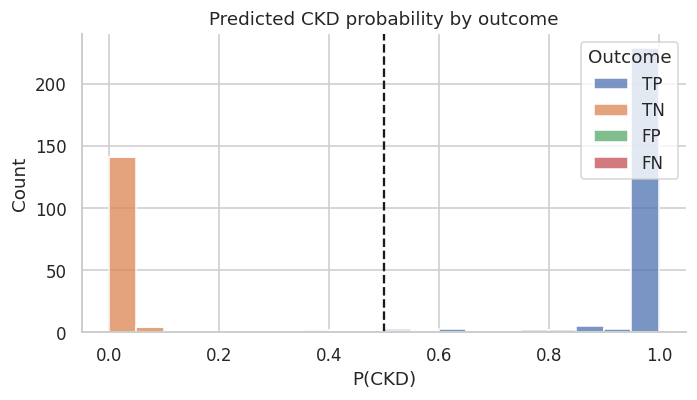

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.histplot(data=allc.assign(Outcome=allc.outcome), x="p_ckd", hue="Outcome", bins=20, multiple="stack", ax=ax)
ax.axvline(0.5, color="k", ls="--"); ax.set(title="Predicted CKD probability by outcome", xlabel="P(CKD)")
plt.tight_layout(); savefig("error_probability_hist.png"); plt.show()

### Observations (descriptive, from this tiny sample)
- Only a handful of patients are misclassified out of 400 predictions (320 out-of-fold + 80 test), so **no statistical conclusion or medical claim is possible**.
- The errors have predicted probabilities close to 0.5, i.e. the model was uncertain about them - they are borderline cases rather than confident mistakes.
- The errors have **more missing values** than typical correctly-classified non-CKD patients, so imputed values (typical-patient values) probably blurred their profile. The missed CKD cases also have relatively normal-looking values on some key features (e.g. an urine albumin grade of 0 or hemoglobin near the healthy range), overlapping with non-CKD patients.
- This supports: (1) better missing-data handling, (2) probability calibration/threshold discussion, (3) more data - listed as future improvements.

## 10. Conclusions
Hemoglobin/red-cell measures, specific gravity, creatinine, albumin and history flags (hypertension, diabetes, appetite) drive predictions. Errors are few, uncertain, and cluster among patients with many missing tests. Explanations describe the model's behaviour on this dataset, not disease mechanisms.